30JAN25

**Reference**

https://quantum.cloud.ibm.com/

https://learning.quantum.ibm.com/course/variational-algorithm-design/examples-and-applications

https://learning.quantum.ibm.com/tutorial/quantum-approximate-optimization-algorithm

https://quantum.cloud.ibm.com/docs/en/guides/hello-world

# **<center>IBM Quantum Experience Demo</center>**

# **<center>Goal:</center>**

# **<center>How Quantum Computers are solving problems</center>**

# **<center>Optimization – general aspects and challenges</center>**

**<center>Classical</center>**

<center><img src="resources/hyperplane_classical_new1.png" width="800"></center>

<center><img src="resources/hyperplane_quantum.png" width="700"></center> <br />

## Load some packages

In [1]:
import qiskit
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import numpy as np

In [2]:
# useful additional packages
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import numpy as np
import networkx as nx

In [3]:
import rustworkx as rx

In [4]:
print(qiskit.version.get_version_info())

2.0.0


### Weighted Max Cut Problem:

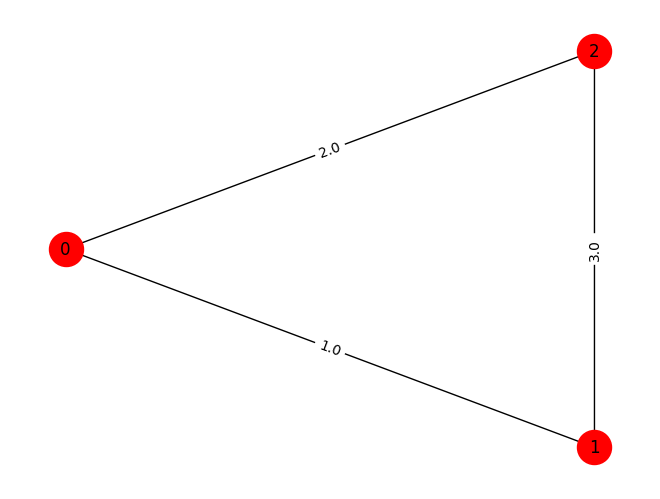

In [5]:
from rustworkx.visualization import mpl_draw
import numpy as np
# Generating a graph of 3 nodes 
n = 3

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, n, 1))
edge_list = [(0, 1, 1.0), (0, 2, 2.0), (1, 2, 3.0)]
graph.add_edges_from(edge_list)

mpl_draw(graph, pos=rx.shell_layout(graph), with_labels=True, edge_labels=str,node_size=600, node_color="red")

Nodes and edges.

Here we have $n = 3$ red nodes edges.

Each edge carries a weight.

The weights of the edges are 2.0, 3.0 and 1.0 respectively.

### Make some example cuts:

#### Separate node 1 and node 2 from node 0


Cost = 1 + 2 =  3


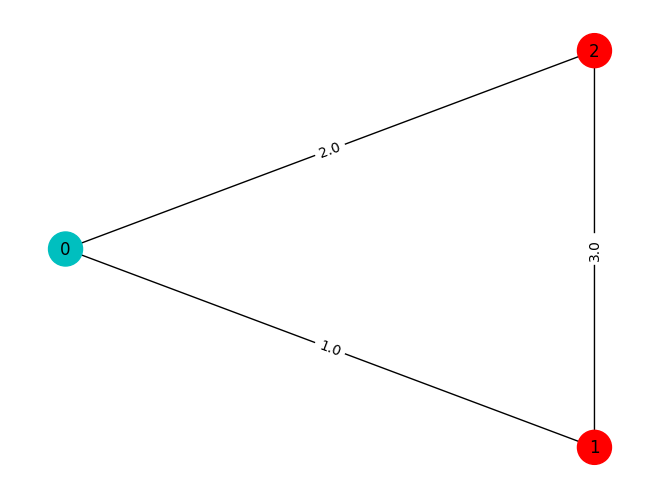

In [6]:
xbest_brute = [1,0,0]

x = np.asarray([int(y) for y in (xbest_brute)])

colors = ["r" if x[i] == 0 else "c" for i in range(n)]
mpl_draw(graph, pos=rx.shell_layout(graph), with_labels=True, edge_labels=str, node_size=600, node_color=colors)

print('\nCost = 1 + 2 = ', 1+2)

red is mapped to 0

blue is mapped to 1

here we have [1, 0, 0]

#### Separate node 1 from node 0 and node 2


Cost = 1 + 3 =  4


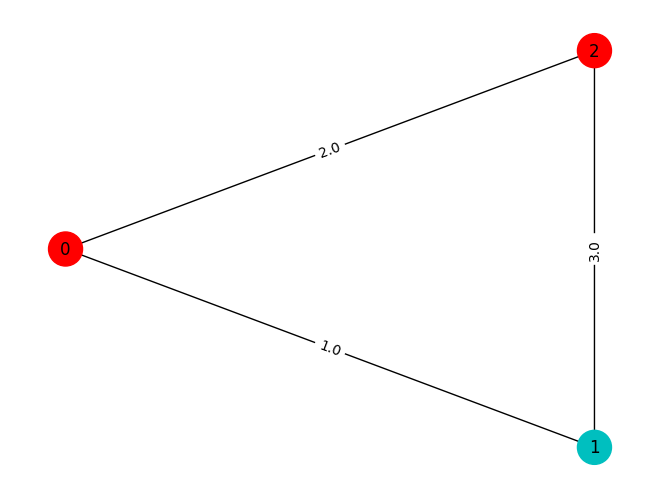

In [7]:
xbest_brute = [0,1,0]
x = np.asarray([int(y) for y in (xbest_brute)])

colors = ["r" if x[i] == 0 else "c" for i in range(n)]
mpl_draw(graph, pos=rx.shell_layout(graph), with_labels=True, edge_labels=str, node_size=600, node_color=colors)

print('\nCost = 1 + 3 = ', 1+3)

here we have [0, 1, 0]

### The goal is to find the ultimate cut that gives the highest cost.

## Weighted Max-Cut Examples:

1) Optimize layout of electronic circuits

2) Design verification

3) Production scheduling optimization

4) Yield Optimization

5) Supply chain optimizing

6) Supply chain disruption recovery

and more

 ### 2.2. Calculating the Max-Cut problem using the Brute force approach

Try all possible $2^n$ combinations. 

For $n = 3$ -> 8 combinations (as in the present example)

For $n = 10$ -> 1024 combinations

For $n = 50$ -> 1 125 899 906 842 624

For $n = 127$ -> 170 141 183 460 469 231 731 687 303 715 884 105 728

For $n = 275 $ -> 60 708 402,882 054,033 466 233 184 588 234 965 832 575 213 720 379 360 039 119 137 804 340 758 912 662 765 568 

($\approx$ 6.1 x $10^{82}$) More combinations than there are Atoms in the observable Universe. 

This is a hard problem.

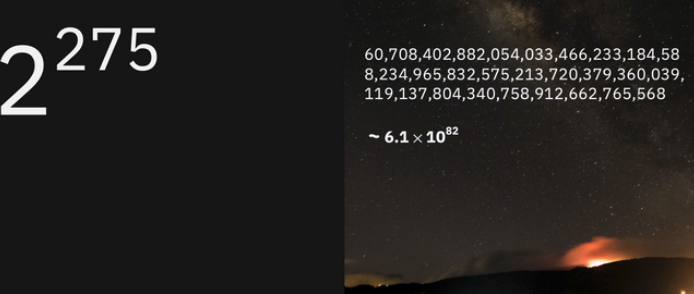

In [8]:
# Weight matrix from the above 3-node example
w = np.array([[0, 1,2], [1, 0,3],[2, 3,0]])

print (w)

[[0 1 2]
 [1 0 3]
 [2 3 0]]


case = [0, 0, 0] cost = 0
case = [1, 0, 0] cost = 3
case = [0, 1, 0] cost = 4
case = [1, 1, 0] cost = 5
case = [0, 0, 1] cost = 5
case = [1, 0, 1] cost = 4
case = [0, 1, 1] cost = 3
case = [1, 1, 1] cost = 0

Best solution = [1, 1, 0] cost = 5


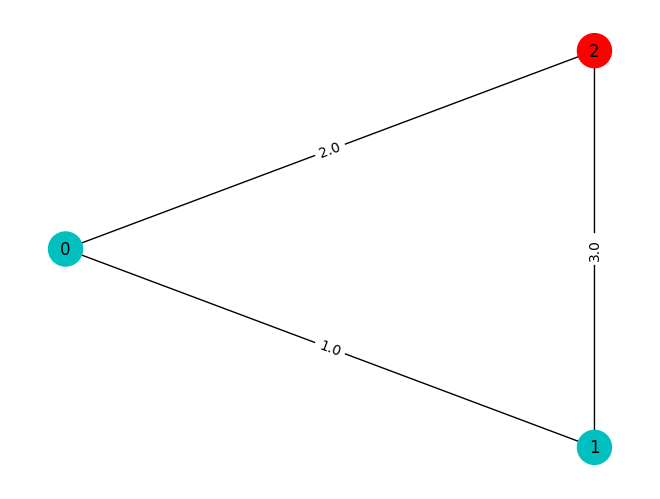

In [10]:
best_cost_brute = 0
for b in range(2**n):
    x = [int(t) for t in reversed(list(bin(b)[2:].zfill(n)))]
    cost = 0
    for i in range(n):
        for j in range(n):
            cost = cost + w[i,j]*x[i]*(1-x[j])
    if best_cost_brute < cost:
        best_cost_brute = cost
        xbest_brute = x 
    print('case = ' + str(x)+ ' cost = ' + str(cost))

colors = ['r' if xbest_brute[i] == 0 else 'c' for i in range(n)]
mpl_draw(graph, pos=rx.shell_layout(graph), with_labels=True, edge_labels=str, node_size=600, node_color=colors)

print('\nBest solution = ' + str(xbest_brute) + ' cost = ' + str(best_cost_brute))

### 2.3. Mapping the Classical Max-Cut Problem to a Quantum Problem

### Small-scale Quantum approximate optimization algorithm (QAOA)

<img src="resources/transformation_new1.png" width="800"><br />

### Hamiltonian → quantum circuit

In [11]:
from qiskit.quantum_info import SparsePauliOp
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    """Convert the graph to Pauli list.

    This function does the inverse of `build_max_cut_graph`
    """
    pauli_list = []
    for edge in list(graph.edge_list()):
        paulis = ["I"] * len(graph)
        paulis[edge[0]], paulis[edge[1]] = "Z", "Z"

        weight = graph.get_edge_data(edge[0], edge[1])

        pauli_list.append(("".join(paulis)[::-1], weight))

    return pauli_list


max_cut_paulis = build_max_cut_paulis(graph)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IZZ', 'ZIZ', 'ZZI'],
              coeffs=[1.+0.j, 2.+0.j, 3.+0.j])


The Hamiltonian Hc contains the quantum definition of your problem. Next step is to create a quantum circuit that will help sample good solutions from the quantum computer. 

Example with one QAOA layer that contains two parameters: γ and β

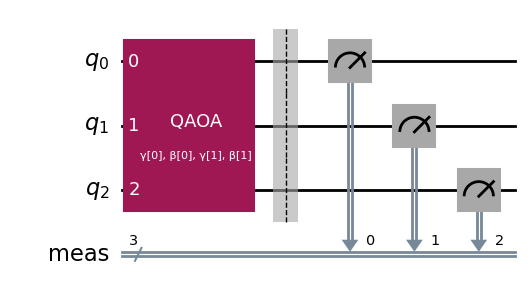

In [12]:
from qiskit.circuit.library import QAOAAnsatz

circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()

circuit.draw('mpl')

In [13]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

## 3 Running it on quantum computer

### Optimize problem for quantum hardware execution

The following code transforms and optimizes the abstract circuit into a format that is ready for execution on one of devices accessible through the cloud using the Qiskit IBM Runtime service.

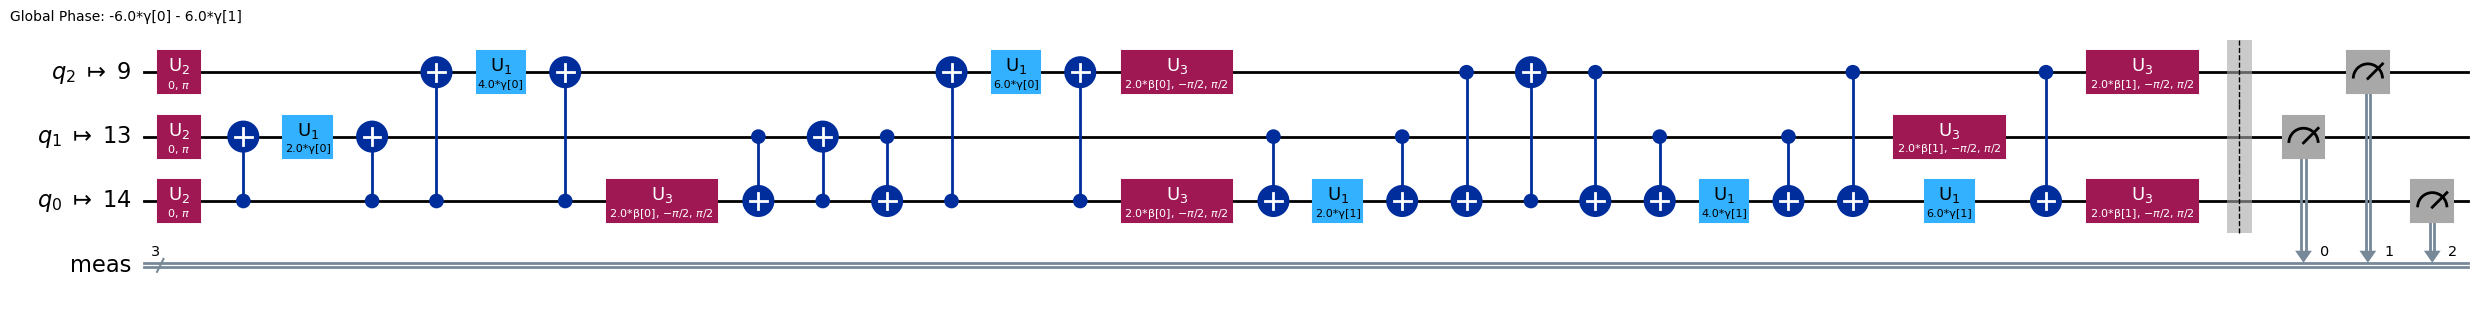

In [14]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import Session, EstimatorOptions
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# Use the following code instead if you want to run on a simulator:
 
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
backend = FakeAlmadenV2()
estimator = Estimator(backend)

# Create pass manager for transpilation
pm = generate_preset_pass_manager(optimization_level=1,
                                    backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw('mpl', fold=False, idle_wires=False)

### Execute using Qiskit primitives

We start with arbitrary chosen parameters.

In [15]:
initial_gamma = np.pi
initial_beta = np.pi/2
init_params = [initial_gamma, initial_beta, initial_gamma, initial_beta]

### QAOA workflow runs iteratively in a session.

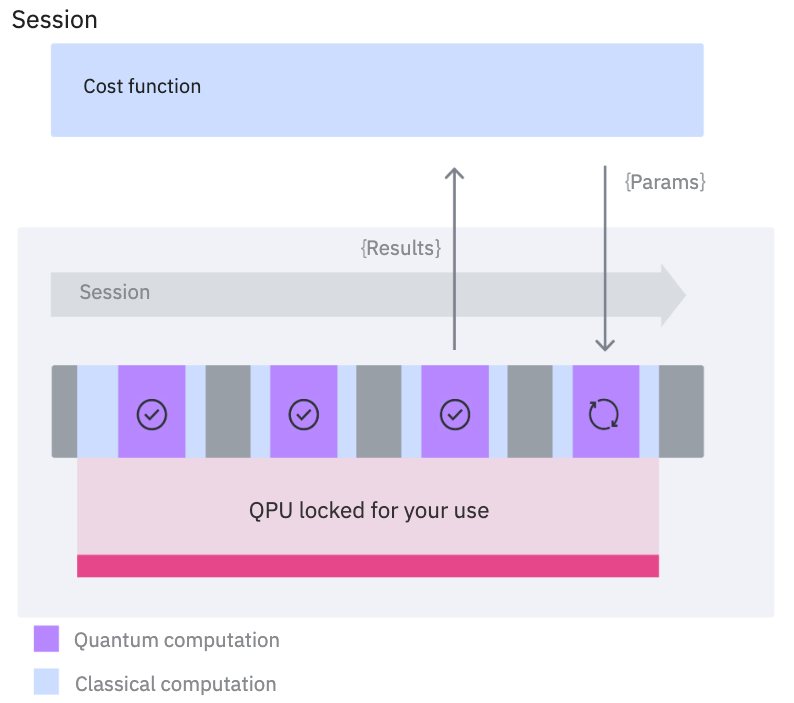

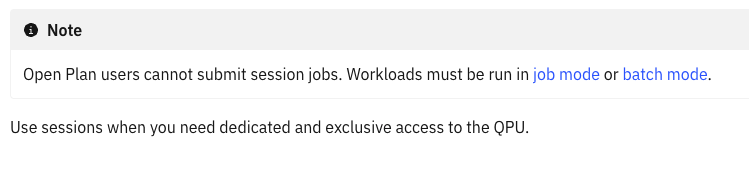

In [16]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):

    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)


    return cost

In [17]:
from scipy.optimize import minimize

objective_func_vals = [] # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000

    # Set simple error suppression/mitigation options
   # estimator.options.dynamical_decoupling.enable = True
  #  estimator.options.dynamical_decoupling.sequence_type = "XY4"
  #  estimator.options.twirling.enable_gates = True
  #  estimator.options.twirling.num_randomizations = "auto"

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: -1.938061938061938
       x: [ 3.920e+00  3.013e+00  4.129e+00  5.601e-01]
    nfev: 26
   maxcv: 0.0


### result.x represents the optimum parameters for β[0], β[1], γ[0], γ[1]

### The optimizer was able to reduce the cost and find better parameters for the circuit.

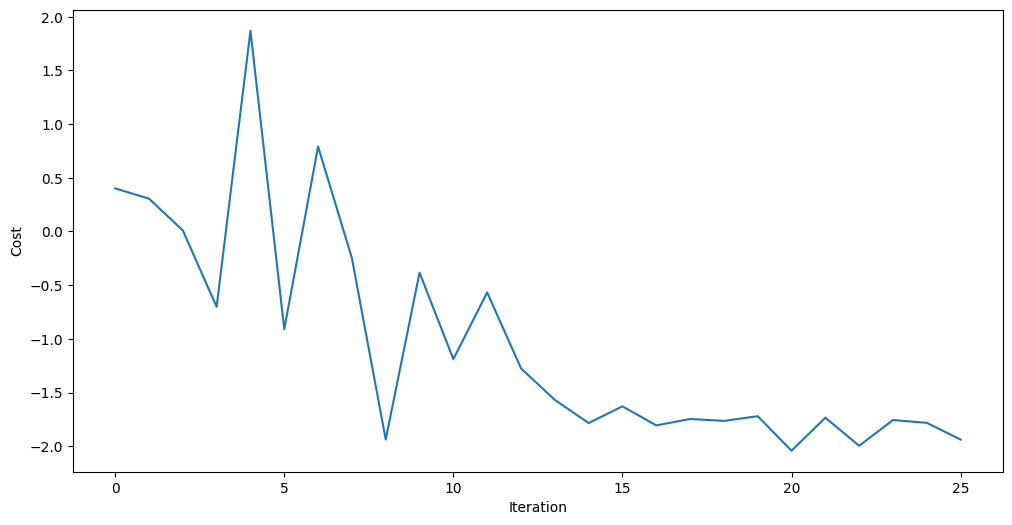

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

Assign these parameters and sample the final distribution obtained with the optimized parameters. Here is where the Sampler primitive should be used since it is the probability distribution of bitstring measurements which correspond to the optimal cut of the graph.

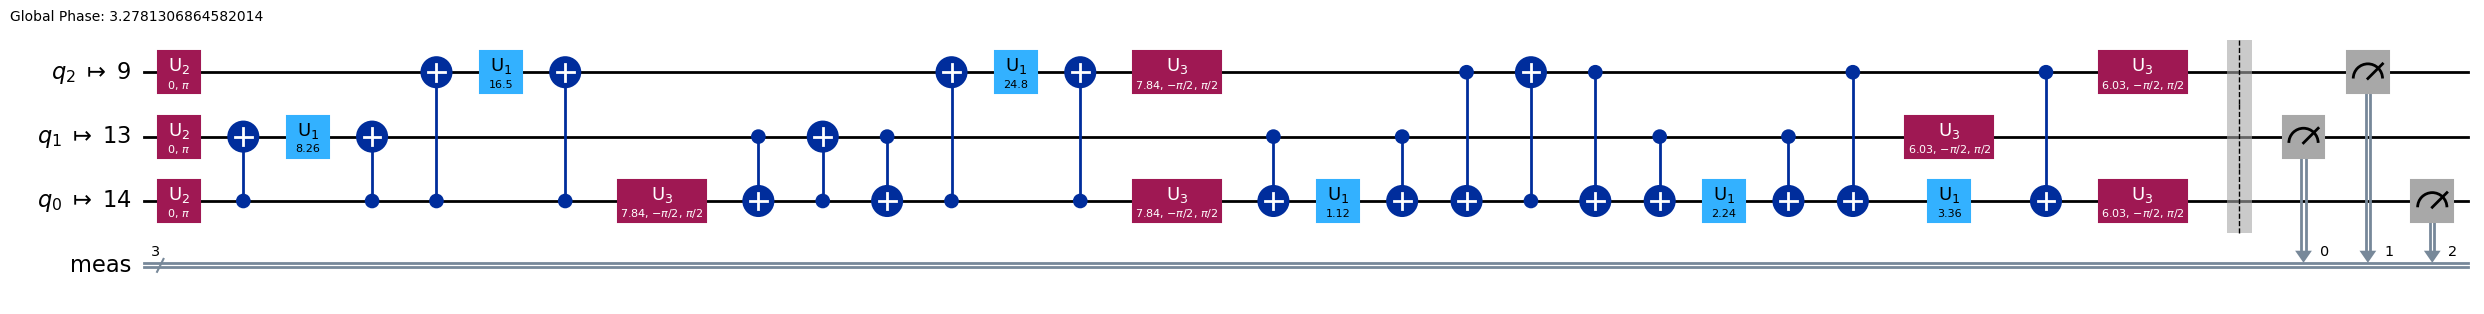

In [19]:
optimized_circuit = candidate_circuit.assign_parameters(result.x)
optimized_circuit.draw('mpl', fold=False, idle_wires=False)

### Sample Primitive

In [20]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# If using qiskit-ibm-runtime<0.24.0, change `mode=` to `backend=`
sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub= (optimized_circuit, )
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val/shots for key, val in counts_int.items()}
final_distribution_bin = {key: val/shots for key, val in counts_bin.items()}
print(final_distribution_int)

/Users/thorsten/miniforge3/envs/qiskit2c/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:269: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


{3: 0.2491, 5: 0.1076, 0: 0.0684, 2: 0.1156, 4: 0.2473, 6: 0.0693, 7: 0.0459, 1: 0.0968}


In [21]:
# auxiliary functions to sample most likely bitstring
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

keys = list(final_distribution_int.keys())
values = list(final_distribution_int.values())
most_likely = keys[np.argmax(np.abs(values))]
most_likely_bitstring = to_bitstring(most_likely, len(graph))
most_likely_bitstring.reverse()

print("Result bitstring:", most_likely_bitstring)

Result bitstring: [1, 1, 0]


/var/folders/wf/7t679s8x7q72hsyk6sw4vsx00000gn/T/ipykernel_13759/3823459478.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.get_children()[int(p)].set_color("tab:purple")


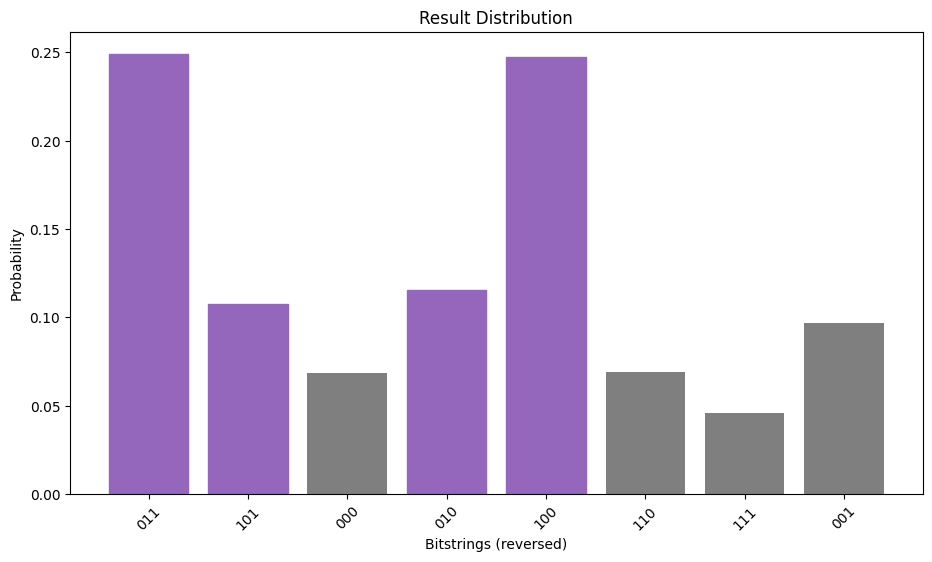

In [22]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams.update({"font.size": 10})
final_bits = final_distribution_bin
values = np.abs(list(final_bits.values()))
top_4_values = sorted(values, reverse=True)[:4]
positions = []
for value in top_4_values:
    positions.append(np.where(values == value)[0])
fig = plt.figure(figsize=(11, 6))
ax = fig.add_subplot(1, 1, 1)
plt.xticks(rotation=45)
plt.title("Result Distribution")
plt.xlabel("Bitstrings (reversed)")
plt.ylabel("Probability")
ax.bar(list(final_bits.keys()), list(final_bits.values()), color="tab:grey")
for p in positions:
    ax.get_children()[int(p)].set_color("tab:purple")
plt.show()

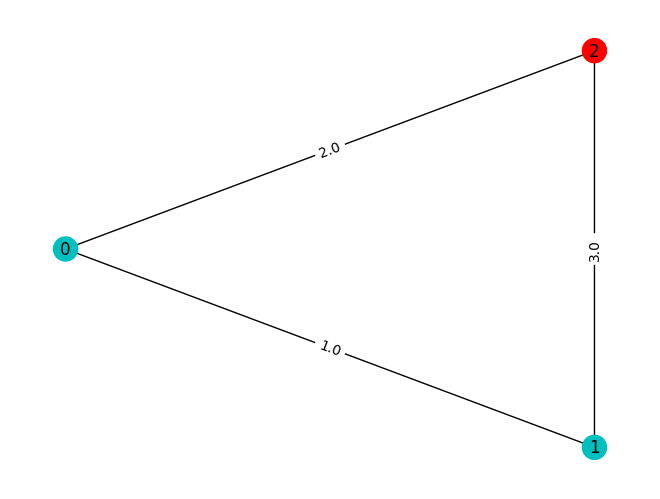

In [23]:
x = np.asarray([int(y) for y in (most_likely_bitstring)])

colors = ["r" if x[i] == 0 else "c" for i in range(n)]
mpl_draw(graph, pos=rx.shell_layout(graph), with_labels=True, edge_labels=str, node_color=colors)

# END

from qiskit_ibm_runtime import QiskitRuntimeService service = QiskitRuntimeService.save_account( token=token, # Your token is confidential. # Do not share your key in public code. instance="crn:v1:bluemix:public:quantum-computing:us-east:a/4a05e99c666d485986a6a60492d8a393:bf32d9db-fb14-4c11-9d62-3015ada78f29::", #name="", # Optionally name this set of account credentials. set_as_default=True, # Optionally set these as your default credentials. overwrite=True )


token = "Pe8yn_2bt9CMbkAwMcPP2_seeJoY0U4JXJEw1bvC3pnw"
